# Сжатие картинок с помощью SVD разложения
В этом задании нужно сделать сжатие изображения, сжатие с потерями. Для этого мы используем SVD разложение.

Примерный порядок действий:
1) Найти любую картинку,
2) Прочитать её с помощью библиотеки PIL
3) Преобразовать в numpy массив
4) Применить SVD к матрице - обязательно прочитайте справку по этой функции `np.linalg.svd`

**Примечание**: Цветная картинка представляет собой трёхканальное изображение RBG, поэтому напрямую SVD разложение применить не получится. Либо вы преобразуете изображение в одноканальное (градации серого), усредняя все три канала. Либо делаете SVD для всех трёх каналов в отдельности.

5) Далее оставляете небольшое количество сингулярных значений - 1, 2, 10, 30, 100. И выводите результат в виде получившейся картинки - чем больше сингулярных чисел, тем ближе приближённая матрица к исходной.

6) Сравните количество байт, необходимых для хранения исходной картинки и сжатой версии.

Ниже представлены основные функции и библиотеки, которые вам понадобятся.

Задание оформляете в виде блокнота jupyter. Особо понравившиеся картинки можно сохранить отдельно на диск, но мне удобнее чтобы они присутствовали в самом jupyter блокноте.

Размер исходного изображения: (262, 350, 3)


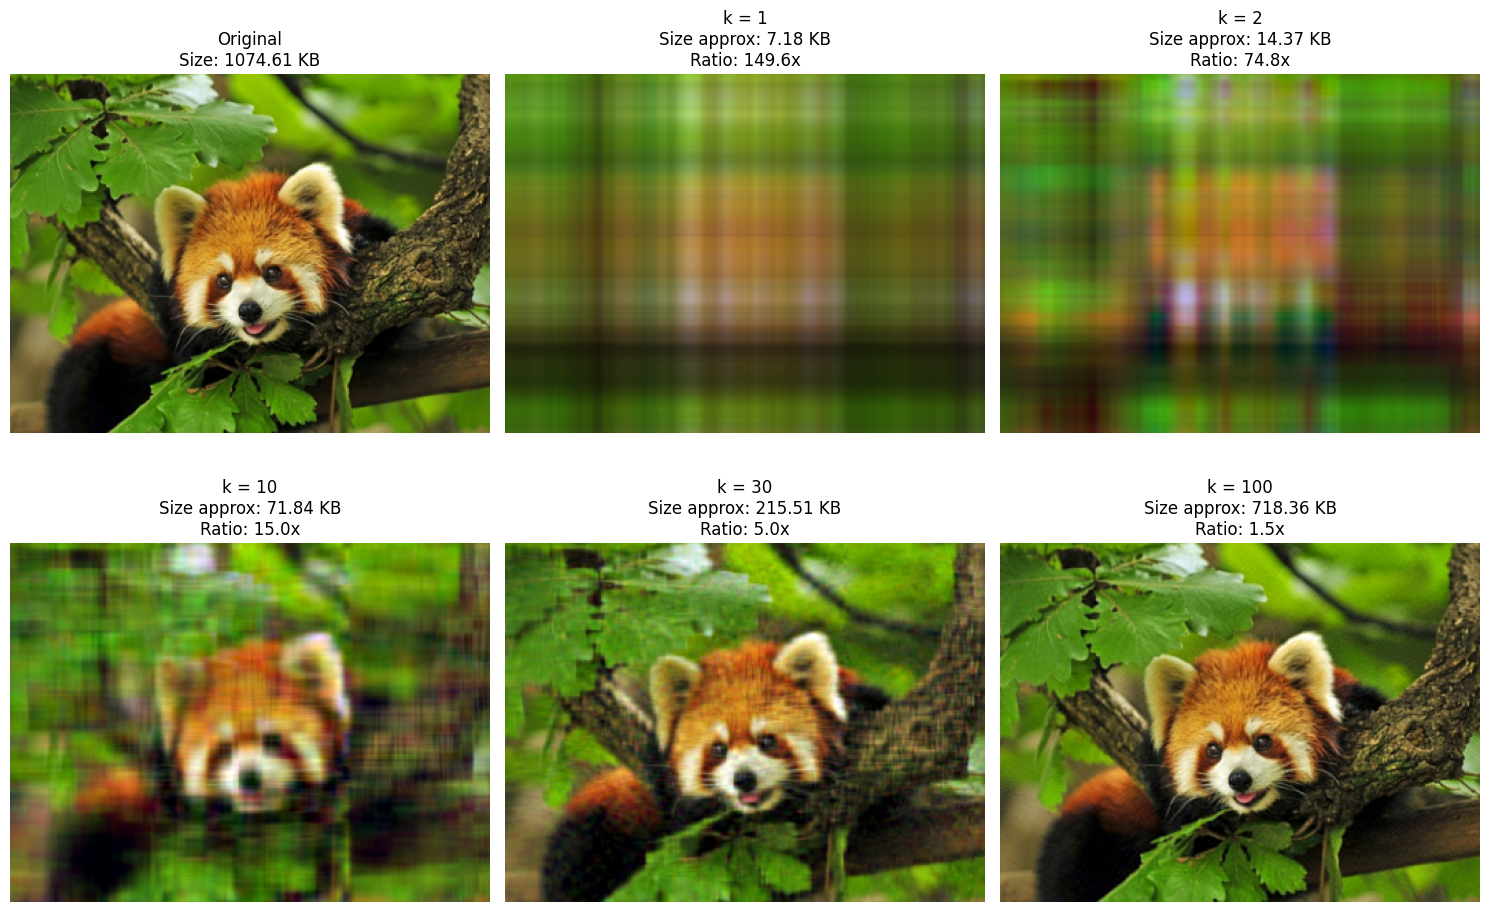


--- Анализ сжатия ---
Исходный размер (несжатый raw bitmap): 1100400 байт
k=1: 7356 байт. Сжатие в 149.59 раз
k=2: 14712 байт. Сжатие в 74.80 раз
k=10: 73560 байт. Сжатие в 14.96 раз
k=30: 220680 байт. Сжатие в 4.99 раз
k=100: 735600 байт. Сжатие в 1.50 раз


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

def compress_image_svd(image_path, k_values):
    # 1. Загрузка изображения
    if not os.path.exists(image_path):
        print(f"Ошибка: Файл {image_path} не найден.")
        return

    img = Image.open(image_path)
    # Уменьшаем для скорости, как в примере, но можно и полное
    w, h = img.size
    img_resized = img.resize((w//2, h//2)) 
    
    # Преобразуем в numpy массив
    img_array = np.array(img_resized, dtype=np.float32)
    
    # Нормализуем значения в диапазон 0-1 для удобства отображения
    img_array /= 255.0

    original_shape = img_array.shape
    print(f"Размер исходного изображения: {original_shape}")

    # Подготовка к визуализации
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    # Оригинальное изображение
    axes[0].imshow(img_array)
    axes[0].set_title(f"Original\nSize: {img_array.nbytes / 1024:.2f} KB")
    axes[0].axis('off')

    # Если изображение цветное (3 канала), применяем SVD к каждому каналу
    # Если ч/б, то просто к 2D матрице
    if len(original_shape) == 3:
        channels = [img_array[:,:,i] for i in range(3)]
    else:
        channels = [img_array]

    # Выполняем SVD для каждого канала
    # full_matrices=False экономит память и время
    svd_results = [np.linalg.svd(c, full_matrices=False) for c in channels]
    
    # Цикл по количеству сингулярных чисел (k)
    for i, k in enumerate(k_values):
        reconstructed_channels = []
        compressed_size_bytes = 0
        
        for U, S, Vt in svd_results:
            # Оставляем только k сингулярных чисел
            # U: (m, k), S: (k,), Vt: (k, n)
            U_k = U[:, :k]
            S_k = np.diag(S[:k])
            Vt_k = Vt[:k, :]
            
            # Восстановление: U * S * Vt
            reconstructed_c = np.dot(U_k, np.dot(S_k, Vt_k))
            reconstructed_channels.append(reconstructed_c)
            
            # Расчет занимаемой памяти (теоретический) для сжатого представления
            # Нам нужно хранить U_k, S_k (вектор), Vt_k для каждого канала
            # Элементы float32 (4 байта)
            elements = U_k.size + k + Vt_k.size
            compressed_size_bytes += elements * 4

        # Собираем каналы обратно
        if len(original_shape) == 3:
            reconstructed_img = np.stack(reconstructed_channels, axis=2)
        else:
            reconstructed_img = reconstructed_channels[0]
            
        # Обрезаем значения, выходящие за границы [0, 1] после математических операций
        reconstructed_img = np.clip(reconstructed_img, 0, 1)

        # Визуализация
        ax_idx = i + 1
        if ax_idx < len(axes):
            axes[ax_idx].imshow(reconstructed_img)
            compression_ratio = img_array.nbytes / compressed_size_bytes
            axes[ax_idx].set_title(f"k = {k}\nSize approx: {compressed_size_bytes/1024:.2f} KB\nRatio: {compression_ratio:.1f}x")
            axes[ax_idx].axis('off')

    plt.tight_layout()
    plt.show()

    # Сравнение байт (текстовый вывод)
    print("\n--- Анализ сжатия ---")
    original_bytes = img_array.nbytes
    print(f"Исходный размер (несжатый raw bitmap): {original_bytes} байт")
    
    for k in k_values:
        # Для каждого канала: U(m*k) + S(k) + V(k*n)
        m, n = img_array.shape[0], img_array.shape[1]
        # Для 3 каналов умножаем на 3
        # Размер float32 = 4 байта
        compressed_bytes = 3 * (m * k + k + k * n) * 4
        print(f"k={k}: {compressed_bytes} байт. Сжатие в {original_bytes/compressed_bytes:.2f} раз")

# Запуск
# Убедитесь, что panda.jpg находится в той же папке
if __name__ == "__main__":
    k_values = [1, 2, 10, 30, 100]
    compress_image_svd('panda.jpg', k_values)

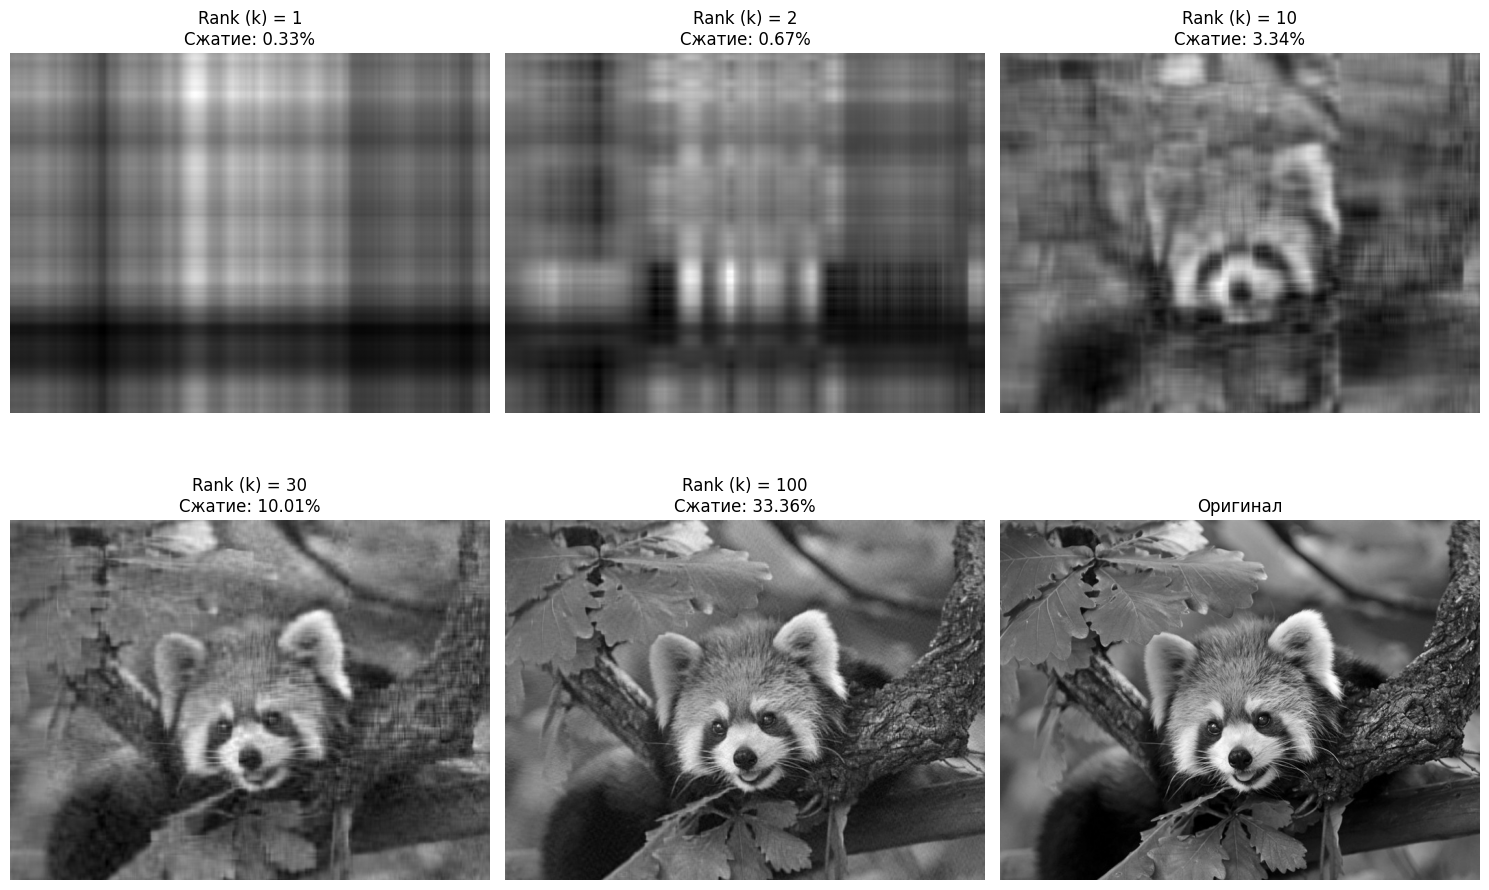

Размер исходной матрицы: 367500 элементов
Для k=  1 нужно элементов:     1226 | Экономия: 99.7%
Для k=  2 нужно элементов:     2452 | Экономия: 99.3%
Для k= 10 нужно элементов:    12260 | Экономия: 96.7%
Для k= 30 нужно элементов:    36780 | Экономия: 90.0%
Для k=100 нужно элементов:   122600 | Экономия: 66.6%


In [4]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

# 1. Загрузка изображения
# Замените 'panda.jpg' на ваш путь к файлу
img_path = 'panda.jpg'
img = Image.open(img_path)

# Опционально: переводим в оттенки серого для простоты (один канал)
# Если хотите оставить цвет, нужно циклом пройти по RGB каналам
img_gray = img.convert('L')
X = np.array(img_gray, dtype=np.float32)

# 2. Функция для сжатия
def compress_svd(matrix, k):
    """
    matrix: исходная матрица
    k: количество оставляемых сингулярных чисел
    """
    U, S, V = np.linalg.svd(matrix, full_matrices=False)
    
    # Реконструкция: берем только k компонент
    # Матрица S возвращается как 1D массив, поэтому используем срез и np.diag
    X_compressed = np.dot(U[:, :k], np.dot(np.diag(S[:k]), V[:k, :]))
    
    # Расчет количества чисел (байтов) для хранения
    # Исходная матрица: m * n
    # Сжатая: (m * k) + k + (k * n)
    m, n = matrix.shape
    original_elements = m * n
    compressed_elements = k * (m + n + 1)
    
    return X_compressed, original_elements, compressed_elements

# 3. Визуализация результатов
ranks = [1, 2, 10, 30, 100]
plt.figure(figsize=(15, 10))

for i, k in enumerate(ranks):
    X_rec, orig_size, comp_size = compress_svd(X, k)
    
    plt.subplot(2, 3, i+1)
    plt.imshow(X_rec, cmap='gray')
    plt.title(f'Rank (k) = {k}\nСжатие: {comp_size/orig_size:.2%}')
    plt.axis('off')

# Добавим оригинал для сравнения
plt.subplot(2, 3, 6)
plt.imshow(X, cmap='gray')
plt.title('Оригинал')
plt.axis('off')

plt.tight_layout()
plt.show()

# 4. Сравнение веса в байтах
print(f"Размер исходной матрицы: {X.shape[0] * X.shape[1]} элементов")
for k in ranks:
    m, n = X.shape
    storage_needed = k * (m + n + 1)
    print(f"Для k={k:3} нужно элементов: {storage_needed:8} | Экономия: {100 * (1 - storage_needed/(m*n)):.1f}%")